# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [2]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [1]:
%pip install --upgrade plotly

### Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [4]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
df_data.shape

(4324, 9)

In [6]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [10]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [11]:
df_data.tail()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [7]:
df_data.isna().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Organisation,0
Location,0
Date,0
Detail,0
Rocket_Status,0
Price,3360
Mission_Status,0


<Axes: >

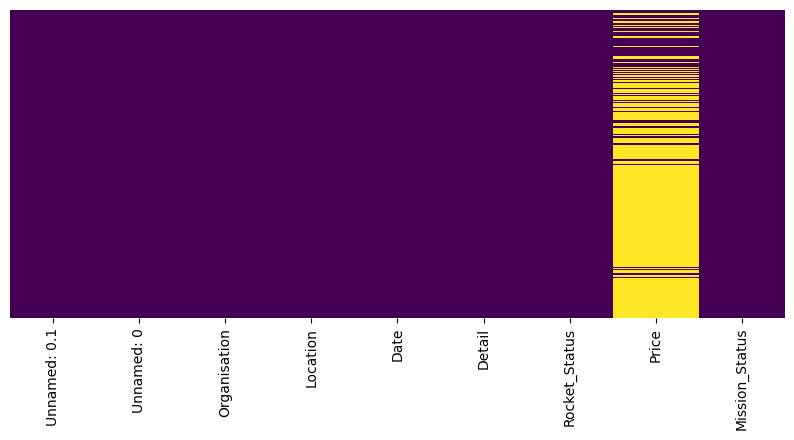

In [9]:
# we have checked about missing data and we don't have any missing data but we will check it with visualization too
plt.figure(figsize=(10,4))
sns.heatmap(df_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [8]:
df_data.duplicated().sum()

np.int64(0)

In [17]:
cleaned_df = df_data.dropna()

In [31]:
df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [20]:
cleaned_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
cleaned_df.head()

/tmp/ipykernel_1723/494094679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


## Descriptive Statistics

In [21]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 964 entries, 0 to 4020
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    964 non-null    object
 1   Location        964 non-null    object
 2   Date            964 non-null    object
 3   Detail          964 non-null    object
 4   Rocket_Status   964 non-null    object
 5   Price           964 non-null    object
 6   Mission_Status  964 non-null    object
dtypes: object(7)
memory usage: 60.2+ KB


In [22]:
cleaned_df.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,964,964,964,964,964,964,964
unique,25,56,963,962,2,56,4
top,CASC,"LC-39A, Kennedy Space Center, Florida, USA","Wed Nov 05, 2008 00:15 UTC",H-IIA 202 | IGS-Radar 5,StatusActive,450.0,Success
freq,158,120,2,2,586,136,910


In [26]:
cleaned_df[cleaned_df["Price"].notna()]["Price"].str.replace(',', '').astype(float).describe()

,Price
count,964.00
mean,153.79
std,288.45
min,5.30
25%,40.00
50%,62.00
75%,164.00
max,"5,000.00"


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [58]:
launches = df_data['Organisation'].value_counts()
print(launches)

Organisation
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
Rocket Lab            13
ISA                   13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
JAXA                   7
Land Launch            7
MITT                   7
UT                     5
CASIC                  5
KCST                   5
Exos                   4
CECLES                 4
Arm??e de l'

/tmp/ipykernel_1723/3967247531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=launches.index, x=launches.values, palette='viridis')


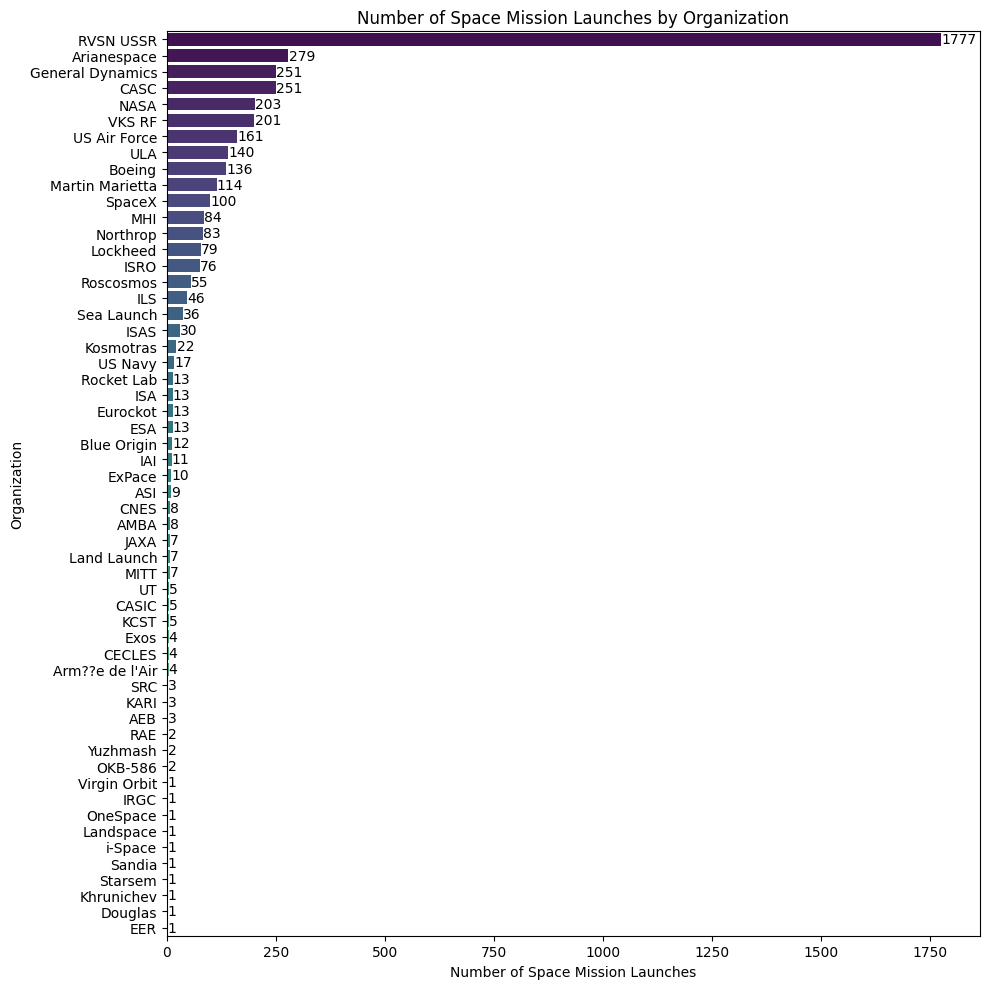

In [59]:
plt.figure(figsize=(10, 10))
sns.barplot(y=launches.index, x=launches.values, palette='viridis')

# Annotate each bar with its value
for i, count in enumerate(launches.values):
    plt.text(count + 0.1, i, str(count), ha='left', va='center')

plt.title('Number of Space Mission Launches by Organization')
plt.xlabel('Number of Space Mission Launches')
plt.ylabel('Organization')
plt.tight_layout()
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [46]:
df_data['Rocket_Status'].value_counts()

,count
Rocket_Status,
StatusRetired,3534
StatusActive,790


In [38]:
cleaned_df[cleaned_df['Rocket_Status'] == 'StatusActive'].count()

,0
Organisation,586
Location,586
Date,586
Detail,586
Rocket_Status,586
Price,586
Mission_Status,586


In [40]:
cleaned_df[cleaned_df['Rocket_Status'] == 'StatusRetired'].count()

,0
Organisation,378
Location,378
Date,378
Detail,378
Rocket_Status,378
Price,378
Mission_Status,378


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [47]:
df_data['Mission_Status'].value_counts()

,count
Mission_Status,
Success,3879
Failure,339
Partial Failure,102
Prelaunch Failure,4


In [42]:
cleaned_df[cleaned_df['Mission_Status'] == 'Success'].count()

,0
Organisation,910
Location,910
Date,910
Detail,910
Rocket_Status,910
Price,910
Mission_Status,910


In [44]:
cleaned_df[cleaned_df['Mission_Status'] == 'Failure'].count()

,0
Organisation,36
Location,36
Date,36
Detail,36
Rocket_Status,36
Price,36
Mission_Status,36


# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

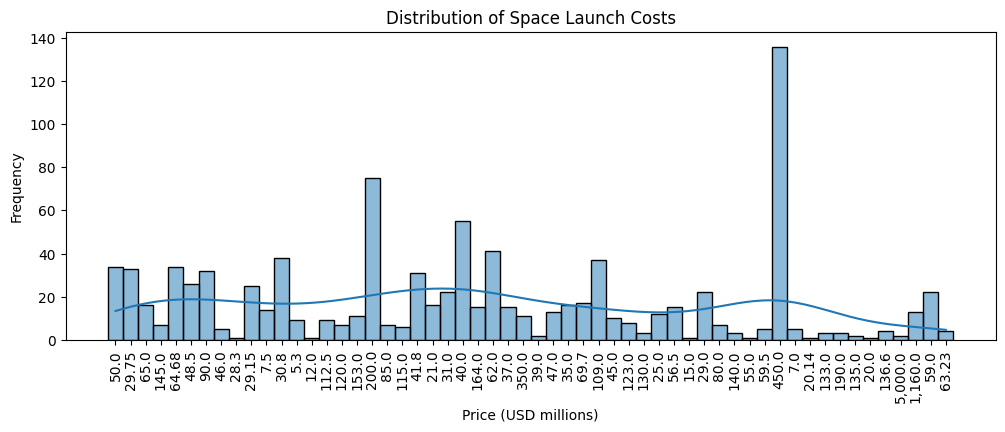

In [63]:
plt.figure(figsize=(12,4))
price = df_data.Price.dropna()
sns.histplot(price, kde=True, bins=30)

plt.xticks(rotation=90)

plt.title('Distribution of Space Launch Costs')
plt.xlabel('Price (USD millions)')
plt.ylabel('Frequency')
plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [64]:
# Wrangle the Country Names
change_country_names = {
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA'
}

# Apply country name changes
df_data['Location'] = df_data['Location'].replace(change_country_names)

# Extract country names
def extract_country(location):
  parts = location.split(', ')
  country_name = parts[-1]
  return country_name

df_data['Country'] = df_data['Location'].apply(extract_country)

In [65]:
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA


In [72]:
iso_codes = {}

for country_name in df_data['Country'].unique():
  try:
    iso_code = countries.get(country_name).alpha3
    iso_codes[country_name] = iso_code
  except:
    pass

# Map countries to ISO codes
df_data['ISO'] = df_data['Country'].map(iso_codes)

# Calculate number of launches per country
launches_by_country = df_data['ISO'].value_counts().reset_index()
launches_by_country.columns = ['ISO', 'Launches']

In [74]:
launches_by_country.head(2)


,ISO,Launches
0,USA,1344
1,KAZ,701


In [75]:
# Create choropleth map using Plotly
fig = px.choropleth(launches_by_country,
                    locations='ISO',
                    color='Launches',
                    hover_name='ISO',
                    color_continuous_scale='matter',
                    title='Number of Launches by country')
fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [80]:
failed_mission = df_data[df_data['Mission_Status'] == 'Failure']

# Number of failures per country
failures_by_country = failed_mission['ISO'].value_counts().reset_index()
failures_by_country.columns = ['ISO', 'Failures']

# Create choropleth map using Plotly
fig = px.choropleth(failures_by_country,
                    locations='ISO',
                    color='Failures',
                    hover_name='ISO',
                    color_continuous_scale='matter',
                    title='Number of Failures by country')
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [82]:
fig = px.sunburst(df_data, path=['Country', 'Organisation', 'Mission_Status'], width=800, height=800)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [86]:
# Convert price column to numeric
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')
total_spendings = df_data.groupby('Organisation')['Price'].sum().reset_index()
total_spendings = total_spendings.sort_values(by='Price', ascending=False)
total_spendings


,Organisation,Price
35,NASA,"61,200.00"
3,Arianespace,"16,345.00"
48,ULA,"14,798.00"
7,CASC,"6,340.26"
46,SpaceX,"5,444.00"
36,Northrop,"3,930.00"
32,MHI,"3,532.50"
23,ISRO,"2,177.00"
49,US Air Force,"1,550.92"
52,VKS RF,"1,548.90"


# Analyse the Amount of Money Spent by Organisation per Launch

In [92]:
total_spendings = df_data.groupby('Organisation')['Price'].sum()
launch_count = df_data['Organisation'].value_counts()

# Calculated amount spent per launch
amount_per_launch = total_spendings / launch_count

launch_df = pd.DataFrame({'Total Amount Spent': total_spendings,
                          'Launch Count': launch_count,
                          'Amount Spent per Launch': amount_per_launch})
launch_df

,Total Amount Spent,Launch Count,Amount Spent per Launch
Organisation,,,
AEB,0.00,3,0.00
AMBA,0.00,8,0.00
ASI,0.00,9,0.00
Arianespace,"16,345.00",279,58.58
Arm??e de l'Air,0.00,4,0.00
Blue Origin,0.00,12,0.00
Boeing,"1,241.00",136,9.12
CASC,"6,340.26",251,25.26
CASIC,0.00,5,0.00


# Chart the Number of Launches per Year

In [93]:
df_data.Date.head(3)

,Date
0,"Fri Aug 07, 2020 05:12 UTC"
1,"Thu Aug 06, 2020 04:01 UTC"
2,"Tue Aug 04, 2020 23:57 UTC"


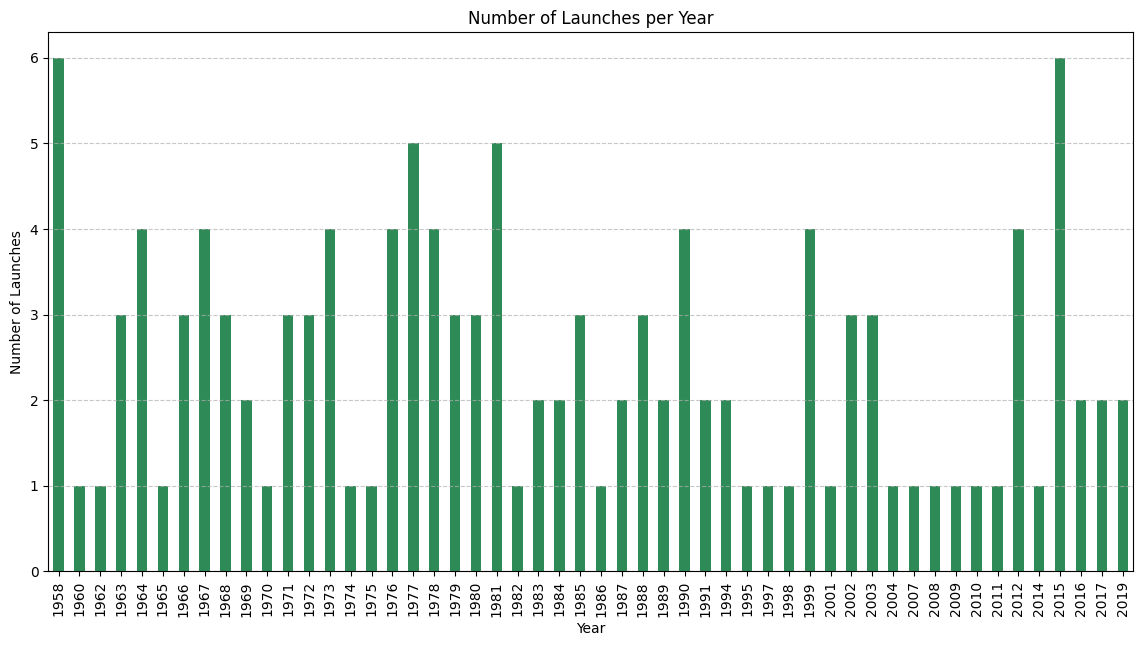

In [103]:
# Convert DATE column to datetime
df_data['Date'] = pd.to_datetime(df_data['Date'], format='%a %b %d, %Y', errors='coerce')

# Drop rows with NaT (missing values)
df_data = df_data.dropna(subset=['Date'])

# Extract Year form DATE column
df_data['Year'] = df_data['Date'].dt.year

# Count number of launches per year
launches_per_year = df_data['Year'].value_counts().sort_index()

# Plot number of launches per year
plt.figure(figsize=(14,7))
launches_per_year.plot(kind='bar', color='seagreen')

plt.title('Number of Launches per Year')
plt.xlabel('Year')
plt.ylabel('Number of Launches')

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [110]:
# Extract month name from 'Date' column
df_data['Month'] = df_data['Date'].dt.strftime('%B')  # %B gives full month name, %b gives abbreviated month name

launches_per_month = df_data.groupby('Month').size()

# calculate rolling average
rolling_avg = launches_per_month.rolling(window=12).mean()


In [112]:
# Find the month with highest number of launches
max_launches_month = launches_per_month.idxmax()
max_launches_count = launches_per_month.max()
print(f"The month with the highest number of launches is {max_launches_month} with {max_launches_count} launches.")

The month with the highest number of launches is December with 20 launches.


# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

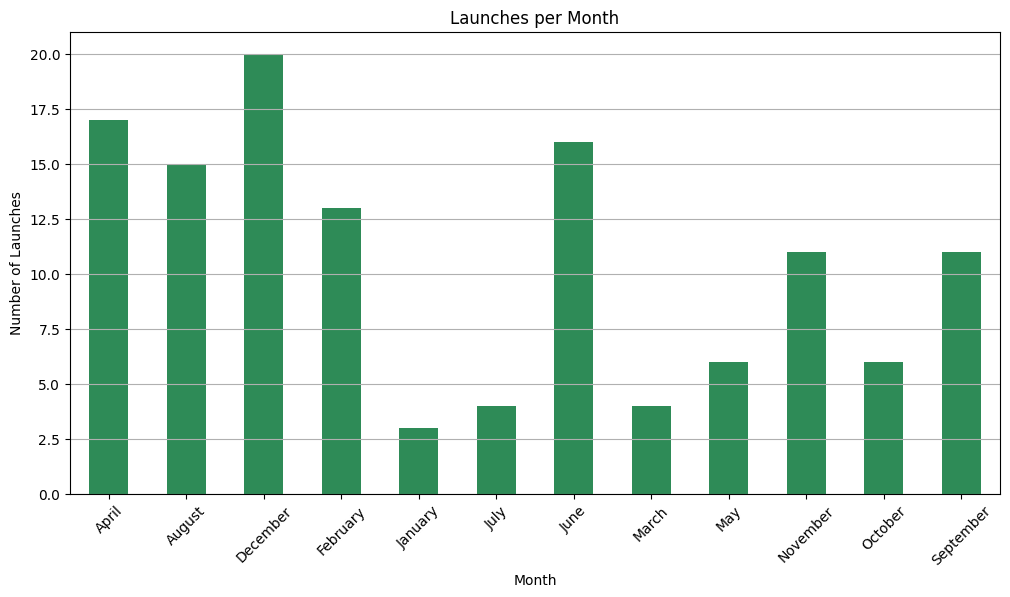

In [120]:
# Plot the distribution of launches across different months
plt.figure(figsize=(12, 6))
launches_per_month.plot(kind='bar', color='seagreen')

plt.title('Launches per Month')
plt.xlabel('Month')
plt.ylabel('Number of Launches')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [121]:
# Identify the most popular and least popular months for launches

most_popular_month = launches_per_month.idxmax()
least_popular_month = launches_per_month.idxmin()

print(f"The most popular month for launches is {most_popular_month}, with {launches_per_month.max()} launches.")
print(f"The least popular month for launches is {least_popular_month}, with {launches_per_month.min()} launches.")

The most popular month for launches is December, with 20 launches.
The least popular month for launches is January, with 3 launches.


# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

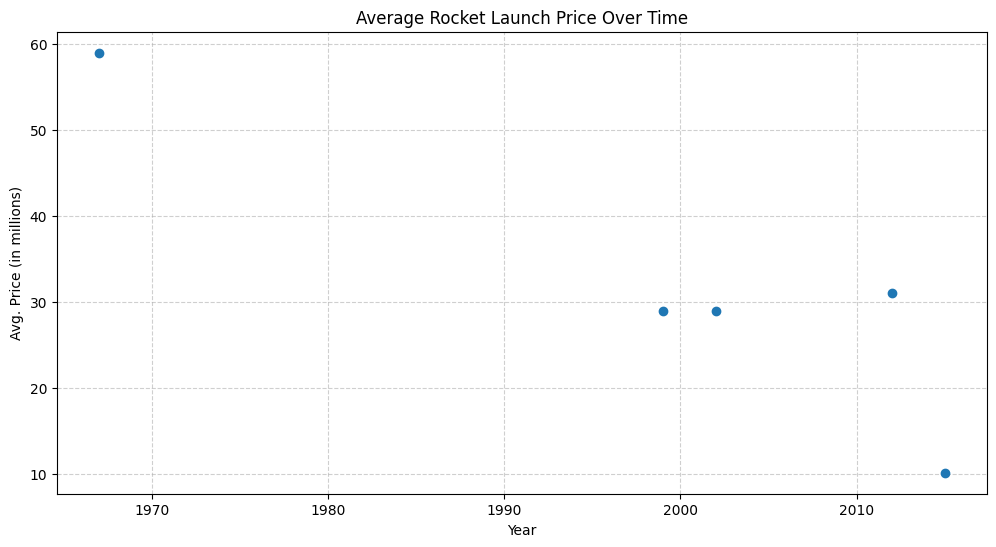

In [129]:
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

# Group by 'Year' and calculate the average price for each year
average_price_per_year = df_data.groupby('Year')['Price'].mean().reset_index()

# Plot the average price over time
plt.figure(figsize=(12, 6))
plt.plot(average_price_per_year.Year, average_price_per_year.Price, marker='o')
plt.title('Average Rocket Launch Price Over Time')
plt.xlabel('Year')
plt.ylabel('Avg. Price (in millions)')

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [133]:
top_launches = launches[10]
plt.figure(figsize=(10, 10))
sns.barplot(y=top_launches.index, x=top_launches.values, palette='viridis')

# Annotate each bar with its value
for i, count in enumerate(launches.values):
    plt.text(count + 0.1, i, str(count), ha='left', va='center')

plt.title('Number of Space Mission Launches by Organization')
plt.xlabel('Number of Space Mission Launches')
plt.ylabel('Organization')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1723/3512332378.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_launches = launches[10]


AttributeError: 'numpy.int64' object has no attribute 'index'

<Figure size 1000x1000 with 0 Axes>

In [137]:
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,alpha3,ISO,Year,Month
106,ISA,"Imam Khomeini Spaceport, Semnan Space Center, ...",2019-08-29,Safir-1B+ | Nahid-1,StatusActive,NaN,Prelaunch Failure,Iran,Country not found,NaN,2019,August
163,ISA,"Imam Khomeini Spaceport, Semnan Space Center, ...",2019-02-05,Safir-1B+ | Dousti,StatusActive,NaN,Failure,Iran,Country not found,NaN,2019,February
295,Blue Origin,"Blue Origin Launch Site, West Texas, Texas, USA",2017-12-17,New Shepard | NS-7,StatusActive,NaN,Success,USA,USA,USA,2017,December
335,ISA,"Imam Khomeini Spaceport, Semnan Space Center, ...",2017-07-27,Simorgh | Test Flight,StatusActive,NaN,Failure,Iran,Country not found,NaN,2017,July
447,Blue Origin,"Blue Origin Launch Site, West Texas, Texas, USA",2016-04-02,New Shepard | NS-4,StatusActive,NaN,Success,USA,USA,USA,2016,April


In [148]:
# Get Top 10 Organizations
top_10_orgs = df_data['Organisation'].value_counts().head(10).index
df_top_10 = df_data[df_data['Organisation'].isin(top_10_orgs)]

# Extract Year
df_top_10['Year'] = df_top_10['Date'].dt.year
launch_counts = df_top_10.groupby(['Year', 'Organisation']).size().unstack(fill_value=0)

/tmp/ipykernel_1723/3073229424.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['Year'] = df_top_10['Date'].dt.year


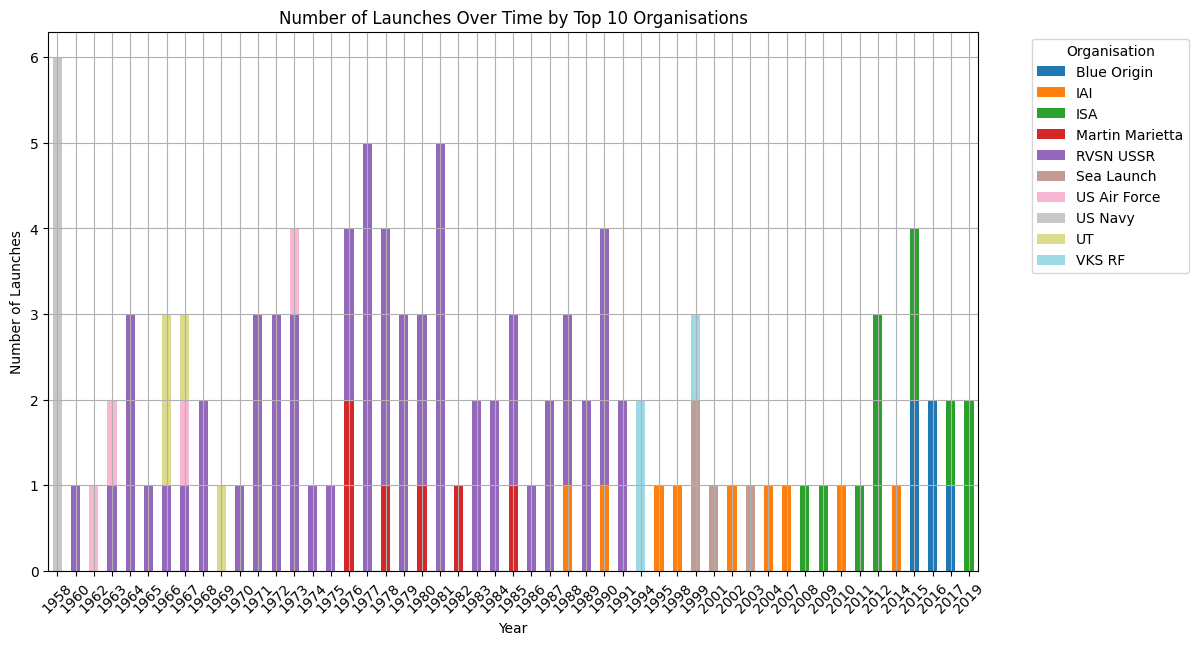

In [160]:
# Plot the stacked bar chart
launch_counts.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Number of Launches Over Time by Top 10 Organisations')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.legend(title='Organisation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [154]:
df_data.Country.unique()

array(['Iran', 'USA', 'Pacific Missile Range Facility', 'China', 'Israel',
       'India', 'Brazil', 'Pacific Ocean', 'Kazakhstan', 'Russia',
       'Japan', 'Australia'], dtype=object)

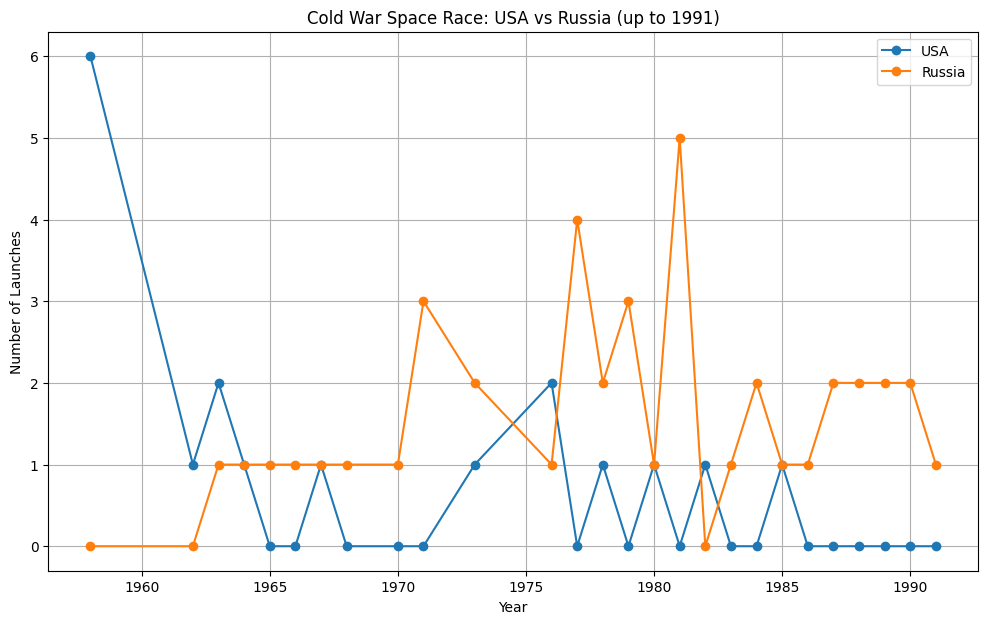

In [159]:
# Filter the dataset to include only launches from USA and USSR up until 1991
cold_war_data = df_data[(df_data['Country'].isin(['USA', 'Russia'])) & (df_data['Year'] <= 1991)]

# Group by 'Year' and 'Country' and count number of launches
cold_war_launch_count = cold_war_data.groupby(['Year', 'Country']).size().unstack(fill_value=0)

# Plot the number of launches per year for USA and USSR
plt.figure(figsize=(12, 7))

plt.plot(cold_war_launch_count.index, cold_war_launch_count['USA'], marker='o', label='USA')
plt.plot(cold_war_launch_count.index, cold_war_launch_count['Russia'], marker='o', label='Russia')

plt.title('Cold War Space Race: USA vs Russia (up to 1991)')
plt.xlabel('Year')
plt.ylabel('Number of Launches')

plt.legend()
plt.grid(True)

plt.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [166]:
# Define the countries that were part of the USSR
ussr_countries = ['Russia', 'Kazakhstan', 'Ukraine', 'Belarus', 'Uzbekistan', 'Turkmenistan',
                  'Azerbaijan', 'Armenia', 'Georgia', 'Latvia', 'Lithuania', 'Estonia', 'Moldova',
                  'Kyrgyzstan', 'Tajikistan']

In [172]:
# Map the countries to 'USSR' or'USA'
df_data['Superpower'] = df_data['Country'].apply(lambda x: 'USSR' if x in ussr_countries else ('USA' if x == 'USA' else 'Other'))

# Filter the dataset to include only launches from 'USA' and 'USSR' up until 1991
cold_war_data = df_data[(df_data['Superpower'].isin(['USA', 'USSR'])) & (df_data['Year'] <= 1991)]

# Calculate total number of launches for each Superpower
launch_counts = cold_war_data['Superpower'].value_counts().reset_index()
launch_counts.columns = ['Superpower', 'Launches']

In [184]:
# Create Pie Chart
fig = px.pie(launch_counts, names='Superpower', values='Launches',
             title='Total Number of Launches: USA vs USSR (up to 1991)',
             color='Superpower',
             color_discrete_map={'USA': 'forestgreen', 'USSR': 'purple'})
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [186]:
# Filter the dataset to include only launches from 'USA' and 'USSR' up until 1991
cold_war_data = df_data[(df_data['Superpower'].isin(['USA', 'USSR'])) & (df_data['Year'] <= 1991)]

# Group by 'Year' and 'Superpower' and count the number of launches
launch_counts_by_year = cold_war_data.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

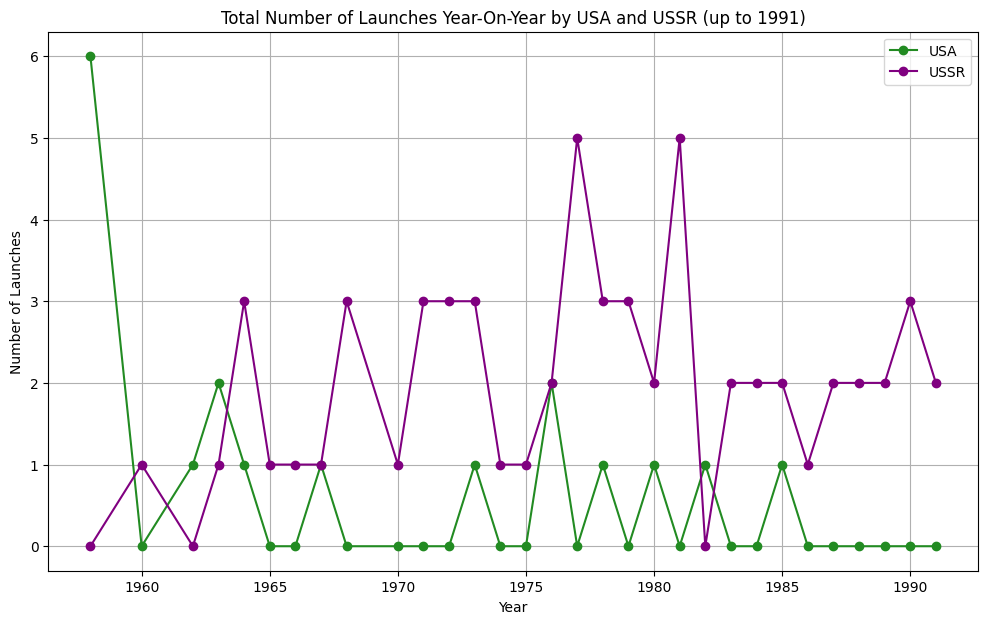

In [187]:
# Plot the results using a line chart
plt.figure(figsize=(12, 7))
plt.plot(launch_counts_by_year.index, launch_counts_by_year['USA'], marker='o', label='USA', color='forestgreen')
plt.plot(launch_counts_by_year.index, launch_counts_by_year['USSR'], marker='o', label='USSR', color='purple')

plt.title('Total Number of Launches Year-On-Year by USA and USSR (up to 1991)')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.legend()
plt.grid(True)
plt.show()

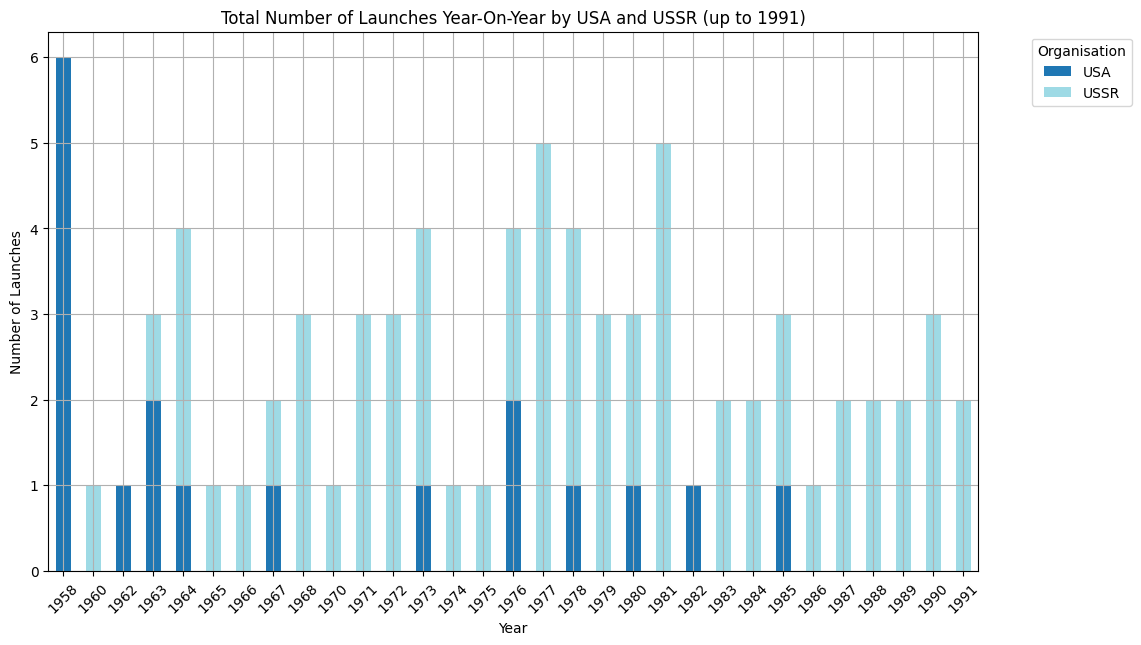

In [189]:
# Plot the stacked bar chart
launch_counts_by_year.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Total Number of Launches Year-On-Year by USA and USSR (up to 1991)')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.legend(title='Organisation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## Chart the Total Number of Mission Failures Year on Year.

In [190]:
# Filter the dataset to include only mission failures
failures_data = df_data[df_data['Mission_Status'] == 'Failure']

# Group by 'Year' and count the number of failures
failures_by_year = failures_data.groupby('Year').size().reset_index(name='Failures')

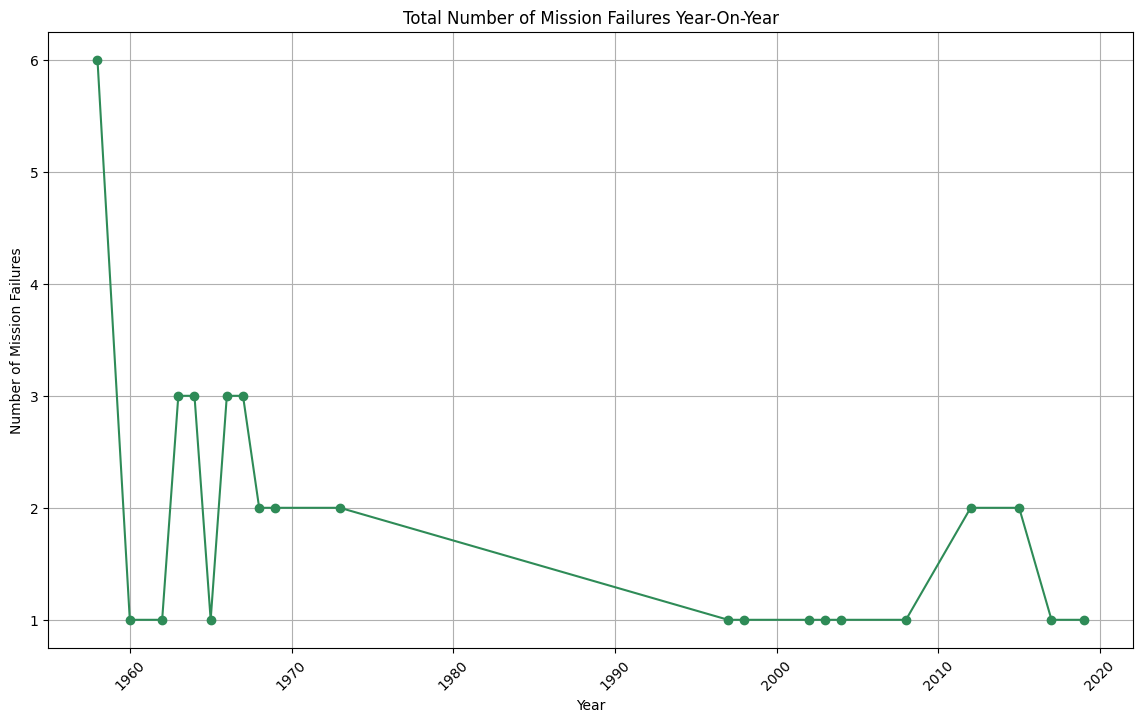

In [198]:
# Plot the results using a line chart
plt.figure(figsize=(14, 8))
plt.plot(failures_by_year['Year'], failures_by_year['Failures'], marker='o', color='seagreen')

plt.title('Total Number of Mission Failures Year-On-Year')
plt.xlabel('Year')
plt.ylabel('Number of Mission Failures')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

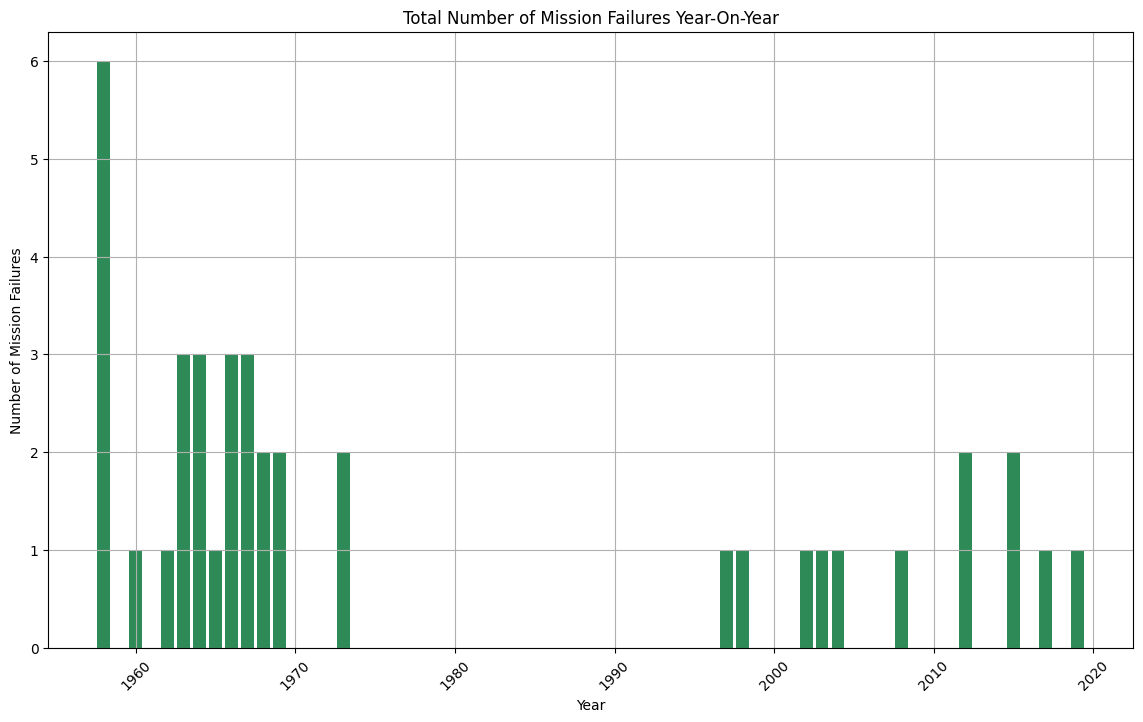

In [199]:
# Plot the results using a bar chart
plt.figure(figsize=(14, 8))
plt.bar(failures_by_year['Year'], failures_by_year['Failures'], color='seagreen')

plt.title('Total Number of Mission Failures Year-On-Year')
plt.xlabel('Year')
plt.ylabel('Number of Mission Failures')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [207]:
# Group by 'Year' and count the total number of launches and failures
launches_by_year = df_data.groupby('Year').size().reset_index(name='Total Launches')
failures_by_year = failures_data.groupby('Year').size().reset_index(name='Failures')

# Merge the two dataframes on 'Year'
failures_percentage = pd.merge(launches_by_year, failures_by_year, on='Year', how='left')

# Fill missing values with 0 (years with no failures)
failures_percentage['Failures'].fillna(0, inplace=True)

# Calculate the percentage of failures for each year
failures_percentage['Failure Percentage'] = (failures_percentage['Failures'] / failures_percentage['Total Launches']) * 100

failures_percentage.head()

/tmp/ipykernel_1723/165323801.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  failures_percentage['Failures'].fillna(0, inplace=True)


,Year,Total Launches,Failures,Failure Percentage
0,1958,6,6.00,100.00
1,1960,1,1.00,100.00
2,1962,1,1.00,100.00
3,1963,3,3.00,100.00
4,1964,4,3.00,75.00


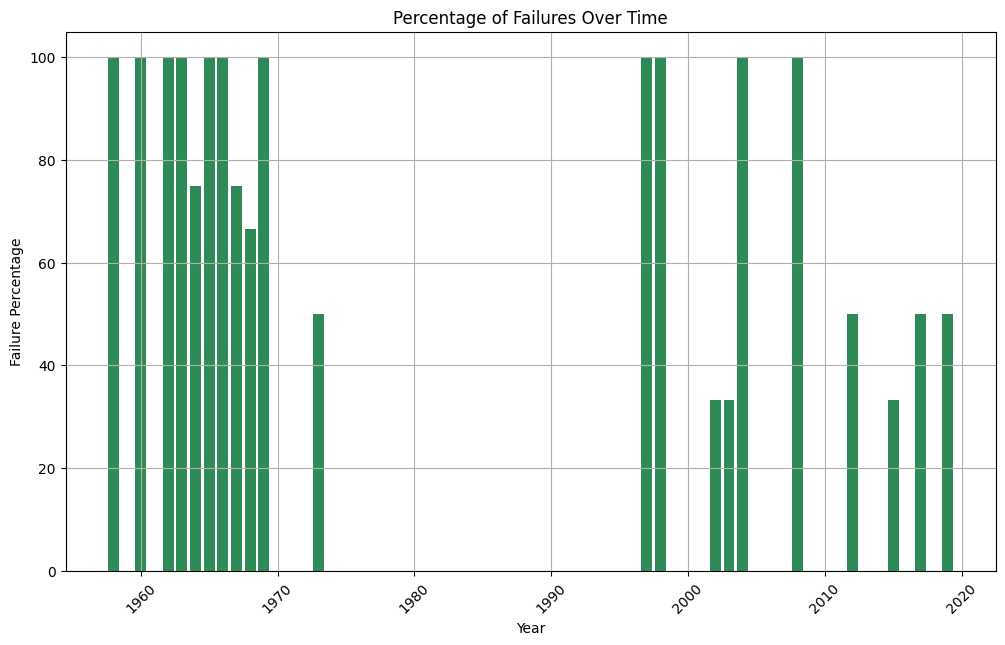

In [210]:
# Plot the results using a bar chart
plt.figure(figsize=(12, 7))
plt.bar(failures_percentage['Year'], failures_percentage['Failure Percentage'], color='seagreen')

plt.title('Percentage of Failures Over Time')
plt.xlabel('Year')
plt.ylabel('Failure Percentage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [215]:
# Filter the dataset to include only launches up to and including 2020
data_up_to_2020 = df_data[df_data['Year'] <= 2020]

# Group by 'Year' and 'Country' and count the number of launches
total_launches_by_year = data_up_to_2020.groupby(['Year', 'Country']).size().unstack(fill_value=0)

# Determine the country with the highest number of launches each year
country_lead_total_launches = total_launches_by_year.idxmax(axis=1)

# Print the results for total launches
print("Country in the lead in terms of total launches each year:")
print(country_lead_total_launches)

Country in the lead in terms of total launches each year:
Year
1958              USA
1960       Kazakhstan
1962              USA
1963              USA
1964       Kazakhstan
1965           Russia
1966            Japan
1967        Australia
1968       Kazakhstan
1969            China
1970           Russia
1971           Russia
1972       Kazakhstan
1973           Russia
1974       Kazakhstan
1975       Kazakhstan
1976              USA
1977           Russia
1978           Russia
1979           Russia
1980       Kazakhstan
1981           Russia
1982              USA
1983       Kazakhstan
1984           Russia
1985       Kazakhstan
1986           Russia
1987           Russia
1988           Russia
1989           Russia
1990           Russia
1991       Kazakhstan
1994       Kazakhstan
1995           Israel
1997           Brazil
1998           Israel
1999    Pacific Ocean
2001    Pacific Ocean
2002            China
2003           Brazil
2004           Israel
2007           Israel
2008         

In [216]:
# Filter the dataset to include only successful launches
successful_launches = data_up_to_2020[data_up_to_2020['Mission_Status'] == 'Success']

# Group by 'Year' and 'Country' and count the number of successful launches
successful_launches_by_year = successful_launches.groupby(['Year', 'Country']).size().unstack(fill_value=0)

# Determine the country with the highest number of launches each year
country_lead_successful_launches = successful_launches_by_year.idxmax(axis=1)

# Print the results for total launches
print("Country in the lead in terms of Successful launches each year:")
print(country_lead_successful_launches)

Country in the lead in terms of Successful launches each year:
Year
1964       Kazakhstan
1967        Australia
1968       Kazakhstan
1970           Russia
1971           Russia
1972       Kazakhstan
1973       Kazakhstan
1974       Kazakhstan
1975       Kazakhstan
1976              USA
1977           Russia
1978           Russia
1979           Russia
1980       Kazakhstan
1981           Russia
1982              USA
1983       Kazakhstan
1984           Russia
1985       Kazakhstan
1986           Russia
1987           Russia
1988           Russia
1989           Russia
1990           Russia
1991       Kazakhstan
1994       Kazakhstan
1995           Israel
1999    Pacific Ocean
2001    Pacific Ocean
2002           Israel
2003    Pacific Ocean
2007           Israel
2009             Iran
2010           Israel
2011             Iran
2012            India
2014           Israel
2015              USA
2016              USA
2017              USA
dtype: object


# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [217]:
# Group by 'Year' and 'Organisation' and count the number of launches
launches_by_year_org = data_up_to_2020.groupby(['Year', 'Organisation']).size().unstack(fill_value=0)

# Determine the organization with the highest number of launches each year
org_lead_by_year = launches_by_year_org.idxmax(axis=1)

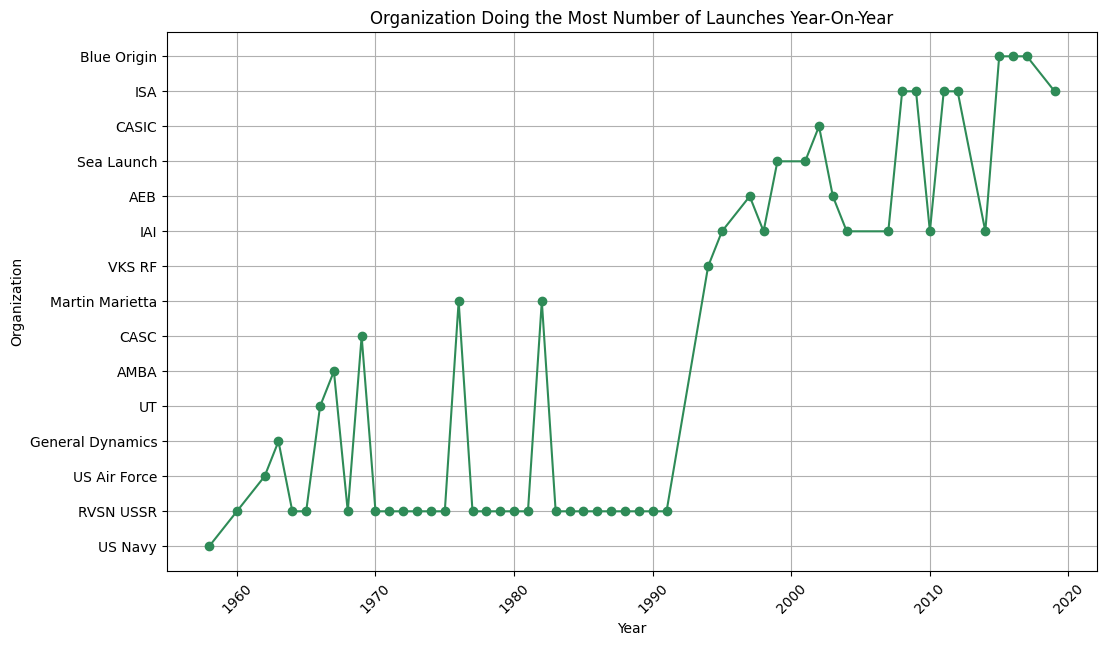

In [220]:
# Plot the results using a line chart
plt.figure(figsize=(12, 7))
plt.plot(org_lead_by_year.index, org_lead_by_year.values, marker='o', color='seagreen')

plt.title('Organization Doing the Most Number of Launches Year-On-Year')
plt.xlabel('Year')
plt.ylabel('Organization')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [221]:
# Filter the dataset to include only launches in 2018, 2019, and 2020
data_2018_to_2020 = df_data[df_data['Year'].isin([2018, 2019, 2020])]

# Group by 'Year' and 'Organisation' and count the number of launches
launches_by_year_org = data_2018_to_2020.groupby(['Year', 'Organisation']).size().unstack(fill_value=0)

# Determine the organization with the highest number of launches in each year
org_lead_2018 = launches_by_year_org.loc[2018].idxmax() if 2018 in launches_by_year_org.index else "No data"
org_lead_2019 = launches_by_year_org.loc[2019].idxmax() if 2019 in launches_by_year_org.index else "No data"
org_lead_2020 = launches_by_year_org.loc[2020].idxmax() if 2020 in launches_by_year_org.index else "No data"

print("Dominant organization in 2018:", org_lead_2018)
print("Dominant organization in 2019:", org_lead_2019)
print("Dominant organization in 2020:", org_lead_2020)

Dominant organization in 2018: No data
Dominant organization in 2019: ISA
Dominant organization in 2020: No data
